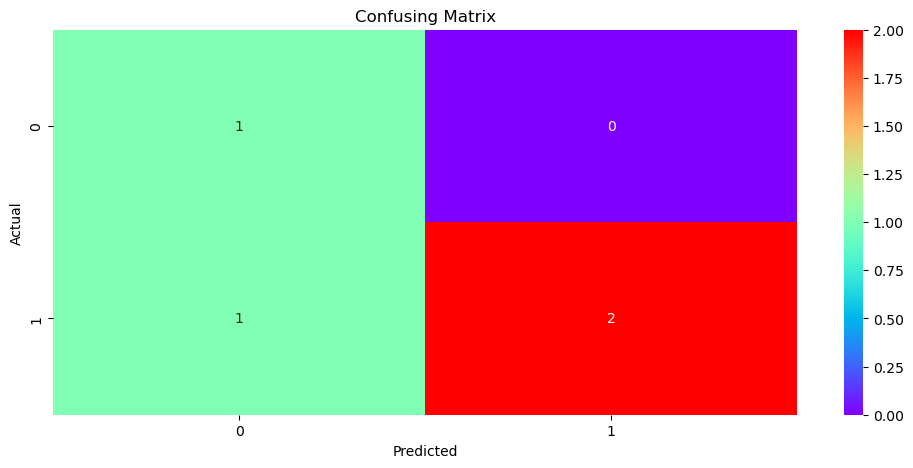

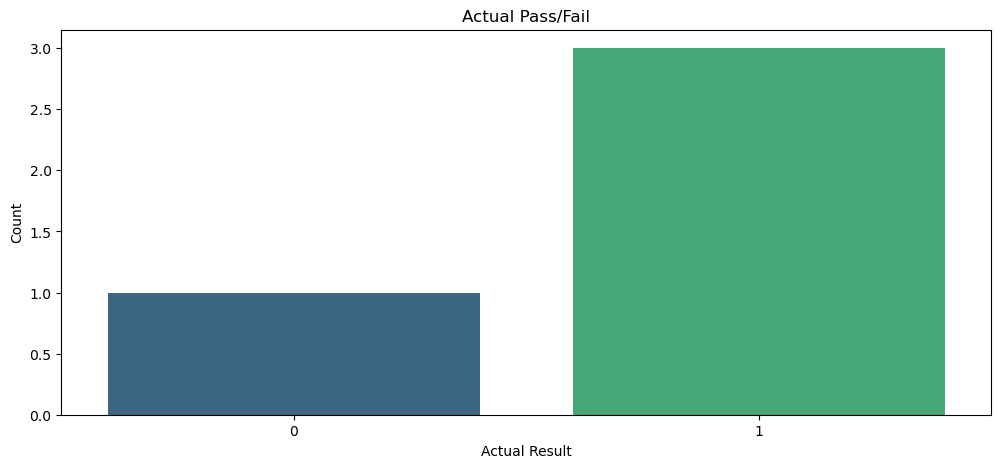

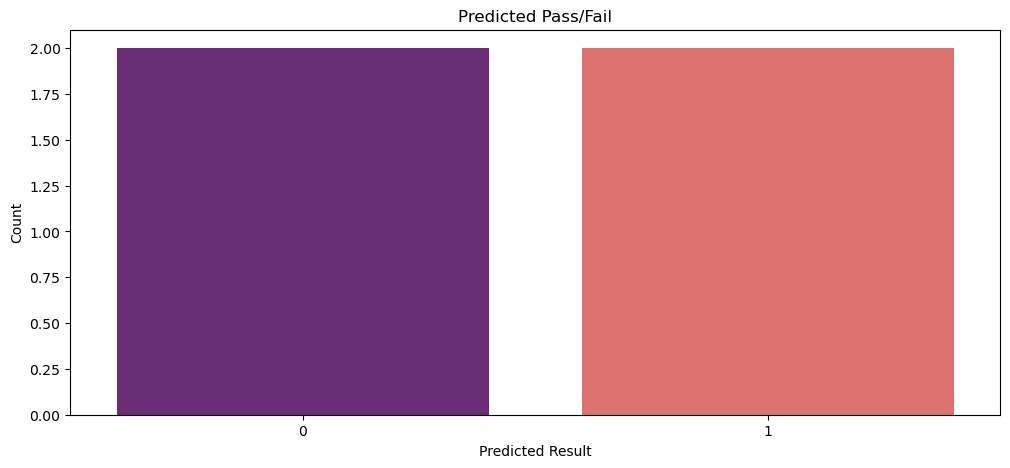

In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix 

data = pd.read_csv('student_dataset.csv')
df = data.copy()
df.isna()
df

le = LabelEncoder() 
df['internet'] = le.fit_transform(df['Internet'])
df['passed'] = le.fit_transform(df['Passed'])
df

features = df[['StudyHours','Attendance','PastScore','internet','SleepHours']]
X = features
y = df['passed']

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model=LogisticRegression()
model.fit(X_train,Y_train)
y_predict = model.predict(X_test)

cm = confusion_matrix(Y_test,y_predict)
fig=plt.figure(figsize=(12,5),dpi=100)
sns.heatmap(cm,annot=True,fmt='d',cmap='rainbow')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title('Confusing Matrix')


fig=plt.figure(figsize=(12,5),dpi=100)
# for actual plot
sns.countplot(x=Y_test,hue=Y_test,palette='viridis',legend=False)
plt.xlabel("Pass score")
plt.xlabel("Actual Result")
plt.ylabel("Count")
plt.title("Actual Pass/Fail")
plt.show()


fig=plt.figure(figsize=(12,5),dpi=100)
# for predicted plot
sns.countplot(x=y_predict,hue=y_predict, palette='magma',legend=False)
plt.xlabel("Predicted Result")
plt.ylabel("Count")
plt.title("Predicted Pass/Fail")
plt.show()

# taking inputs
try:
    study_hrs = float(input("enter the hrs studied"))
    attendnce = float(input("enter the attendence"))
    past_scr = float(input("enter the past score"))
    internet = float(input("enter the internet used"))
    sleep_hrs = float(input("enter how much sleep"))

    sinput = pd.DataFrame({
        'StudyHours': [study_hrs],
        'Attendance': [attendance],
        'PastScore': [past_scr],
        'internet': [internet],
        'SleepHours': [sleep_hrs]
    })
    
    input_df = scaler.transform(sinput) 
    new_predict = model.predict(input_df)[0]
    if new_predict == 1:
        result = 'pass'
    else:
        result='fail'
    print(f"The student is likely to {result}")

except Exception as e:
    print("An error occured",e)


In [4]:
df

,StudyHours,Attendance,PastScore,Internet,SleepHours,Passed,internet,passed
0,2,60,40,Yes,5,No,1,0
1,5,80,60,No,6,Yes,0,1
2,8,90,75,Yes,8,Yes,1,1
3,3,70,50,Yes,5,No,1,0
4,7,85,70,No,7,Yes,0,1
5,1,50,30,No,4,No,0,0
6,6,78,68,Yes,6,Yes,1,1
7,4,65,55,No,5,No,0,0
8,9,95,80,Yes,9,Yes,1,1
9,2,55,35,No,4,No,0,0
